In [12]:
import numpy as np
import torch

data = np.load('data/LEMON_DATA/real_fake.npz')

x_real = torch.from_numpy(data['real']).flatten(1)
x_fake = torch.from_numpy(data['fake']).flatten(1)
x = torch.cat([x_real, x_fake], dim=0).float()

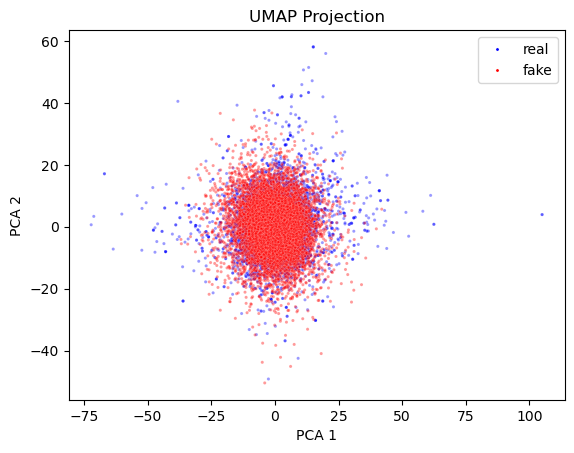

In [61]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.pipeline import make_pipeline

pipe = make_pipeline(
    StandardScaler(),
    PCA(n_components=2),
)

x_pca = pipe.fit_transform(x.numpy())

g = sns.scatterplot(
    x=x_pca[:, 0],
    y=x_pca[:, 1],
    hue=['real'] * len(x_real) + ['fake'] * len(x_fake),
    palette=['blue', 'red'],
    alpha=0.4,
    s=5,
)
g.set_title('UMAP Projection')
g.set_ylabel('PCA 2')
g.set_xlabel('PCA 1')
# change the legend color from 0.1 alpha to 1.0 alpha
handles, labels = g.get_legend_handles_labels()
for artist in handles:
    artist.set_alpha(1.0)
g.legend(handles, labels, loc='upper right')

In [34]:
from umap import UMAP
umapper = UMAP()
x_umap = umapper.fit_transform(x.numpy())

/Users/morteza/workspace/YARE-GAN/.pixi/envs/default/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


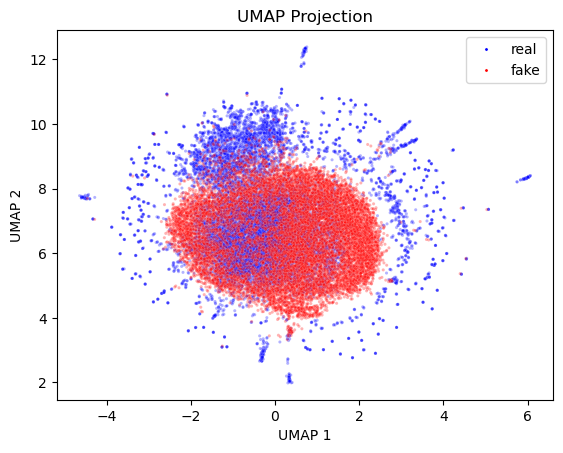

In [58]:
g = sns.scatterplot(
    x=x_umap[:, 0],
    y=x_umap[:, 1],
    hue=['real'] * len(x_real) + ['fake'] * len(x_fake),
    palette=['blue', 'red'],
    alpha=0.3,
    s=5,
)

g.set_title('UMAP Projection')
g.set_ylabel('UMAP 2')
g.set_xlabel('UMAP 1')

# change the legend color from 0.1 alpha to 1.0 alpha
handles, labels = g.get_legend_handles_labels()
for artist in handles:
    artist.set_alpha(1.0)
g.legend(handles, labels, loc='upper right')